In [1]:
import kagglehub
from os import getcwd
import shutil

In [2]:
path = kagglehub.dataset_download(
    "laotse/credit-risk-dataset")
shutil.copytree(path, getcwd(), dirs_exist_ok=True)

Using Colab cache for faster access to the 'credit-risk-dataset' dataset.


'/content'

In [3]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("credit_risk_dataset.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [6]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [7]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [8]:
(df.isnull().mean()*100).sort_values(ascending=False)

,0
loan_int_rate,9.563856
person_emp_length,2.747000
person_income,0.000000
person_age,0.000000
person_home_ownership,0.000000
loan_intent,0.000000
loan_grade,0.000000
loan_amnt,0.000000
loan_status,0.000000
loan_percent_income,0.000000


In [9]:
df.duplicated().sum()

np.int64(165)

In [10]:
pd.crosstab(df['loan_grade'], df['loan_status'], normalize='index')

loan_status,0,1
loan_grade,,
A,0.900436,0.099564
B,0.837240,0.162760
C,0.792660,0.207340
D,0.409542,0.590458
E,0.355809,0.644191
F,0.294606,0.705394
G,0.015625,0.984375


In [11]:
df[df.duplicated(keep=False)].sort_values(
    df.columns.tolist()).to_csv("duplicate.csv", index=False)

In [ ]:
df = df.drop_duplicates().reset_index(drop=True)

In [13]:
pd.crosstab(
    df['person_home_ownership'],
    df['loan_status'],
    normalize='index'
).round(3)

loan_status,0,1
person_home_ownership,,
MORTGAGE,0.874,0.126
OTHER,0.689,0.311
OWN,0.925,0.075
RENT,0.684,0.316


In [14]:
df['house_ownership_risk'] = df['person_home_ownership'].replace({
    'OWN': 'STABLE',
    'MORTGAGE': 'STABLE',
    'RENT': 'NON_STABLE',
    'OTHER': 'NON_STABLE'
})

In [15]:
pd.crosstab(
    df['house_ownership_risk'],
    df['loan_status'],
    normalize='index'
).round(3)

loan_status,0,1
house_ownership_risk,,
NON_STABLE,0.684,0.316
STABLE,0.882,0.118


In [16]:
import matplotlib.pyplot as plt

In [17]:
num_cols = list(df.select_dtypes("number").columns)

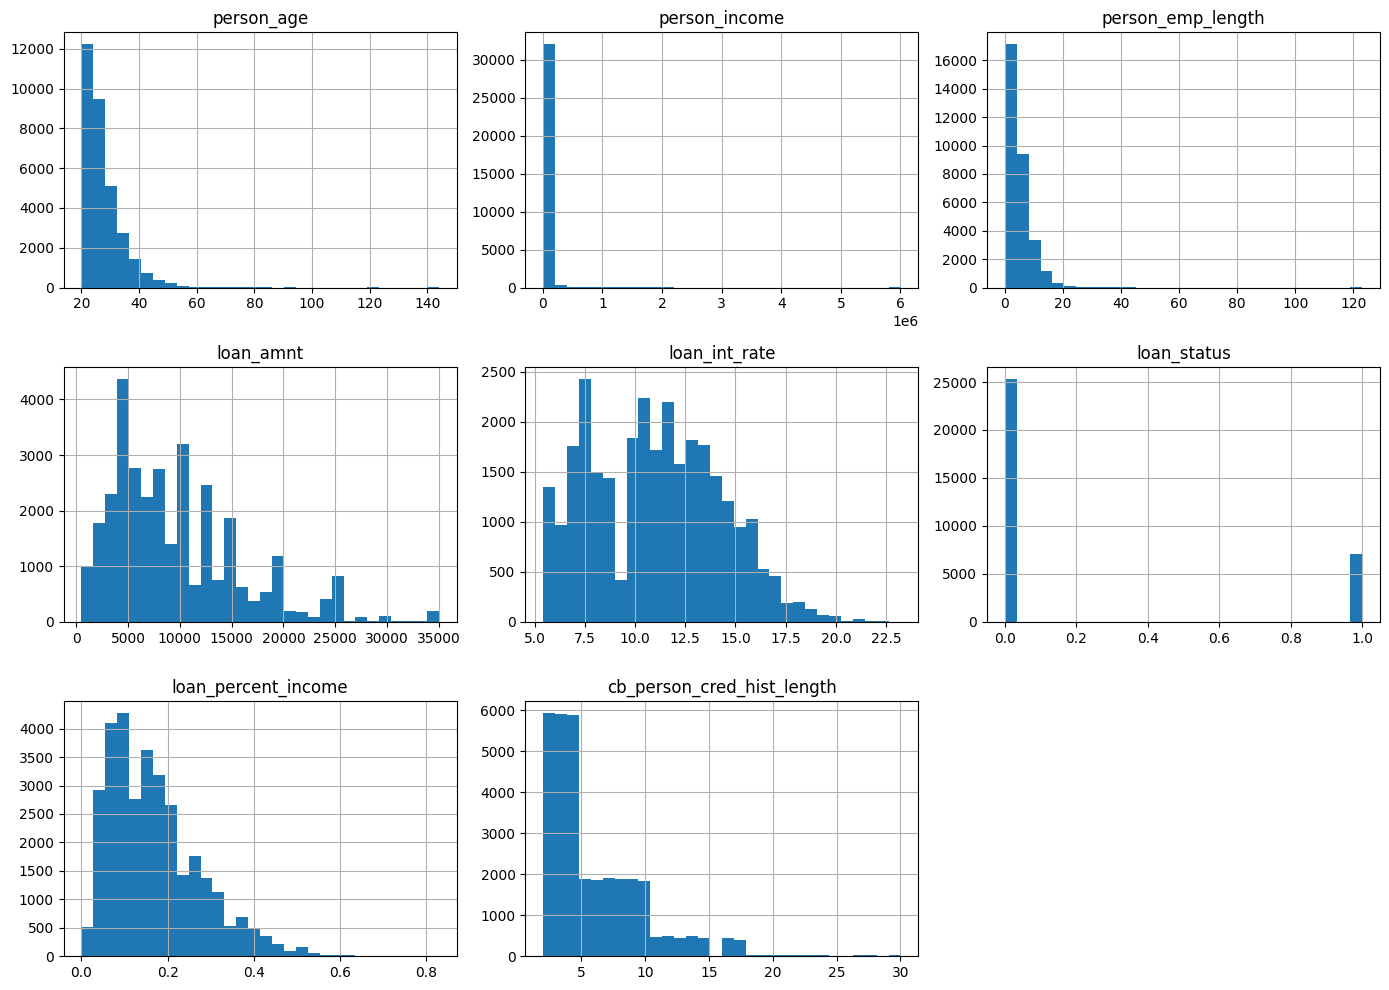

In [18]:
df[num_cols].hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

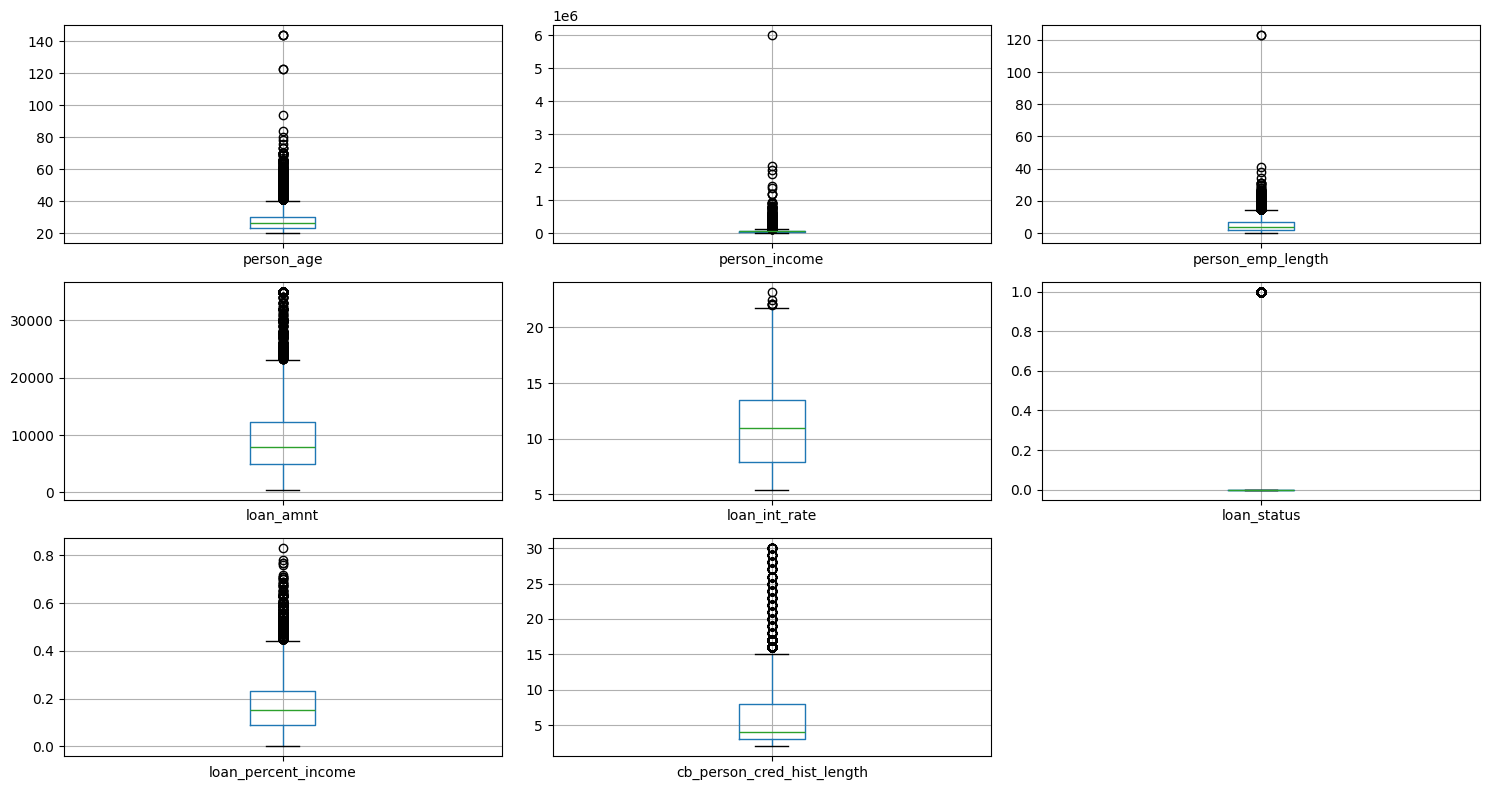

In [19]:
plt.figure(figsize=(15, 8))

for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i+1)
    df.boxplot(column=col)

plt.tight_layout()
plt.show()

In [20]:
df['person_emp_length'].describe()

,person_emp_length
count,31529.00000
mean,4.79051
std,4.14549
min,0.00000
25%,2.00000
50%,4.00000
75%,7.00000
max,123.00000


In [21]:
df['person_emp_length'].value_counts().sort_index().tail(20)

,count
person_emp_length,
16.0,165
17.0,128
18.0,104
19.0,64
20.0,42
21.0,38
22.0,19
23.0,10
24.0,10


## Replace rare outliers with NaN whose values will be put later with KNN Imputation

In [ ]:
df.loc[df['person_emp_length'] == 123,
       'person_emp_length'] = np.nan

In [23]:
df.loc[df['person_age'] >= 45,
       'person_age'] = np.nan

In [24]:
df["cb_person_default_on_file"] = df["cb_person_default_on_file"].apply(lambda x: 0 if x=="N" else 1)

In [25]:
stable_df = df[df['house_ownership_risk'] == 'STABLE'].copy()

nonstable_df = df[df['house_ownership_risk'] == 'NON_STABLE'].copy()

In [26]:
stable_df.drop(columns=["person_home_ownership","house_ownership_risk"], inplace=True)
nonstable_df.drop(columns=["person_home_ownership",
                  "house_ownership_risk"], inplace=True)

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
X_stable = stable_df.drop('loan_status', axis=1)
y_stable = stable_df['loan_status']

X_stable_train, X_stable_temp, y_stable_train, y_stable_temp = train_test_split(
    X_stable,
    y_stable,
    test_size=0.30,
    stratify=y_stable,
    random_state=42
)

X_stable_val, X_stable_test, y_stable_val, y_stable_test = train_test_split(
    X_stable_temp,
    y_stable_temp,
    test_size=0.50,
    stratify=y_stable_temp,
    random_state=42
)

In [29]:
stable_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15932 entries, 1 to 32414
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  15552 non-null  float64
 1   person_income               15932 non-null  int64  
 2   person_emp_length           15411 non-null  float64
 3   loan_intent                 15932 non-null  object 
 4   loan_grade                  15932 non-null  object 
 5   loan_amnt                   15932 non-null  int64  
 6   loan_int_rate               14390 non-null  float64
 7   loan_status                 15932 non-null  int64  
 8   loan_percent_income         15932 non-null  float64
 9   cb_person_default_on_file   15932 non-null  int64  
 10  cb_person_cred_hist_length  15932 non-null  int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 1.5+ MB


In [30]:
from sklearn.impute import KNNImputer

In [31]:
imputer = KNNImputer(n_neighbors=5)

X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_stable_train.select_dtypes("number")),
    columns=X_stable_train.select_dtypes("number").columns,
    index=X_stable_train.select_dtypes("number").index
)

X_val_imp = pd.DataFrame(
    imputer.transform(X_stable_val.select_dtypes("number")),
    columns=X_stable_val.select_dtypes("number").columns,
    index=X_stable_val.select_dtypes("number").index
)

X_test_imp = pd.DataFrame(
    imputer.transform(X_stable_test.select_dtypes("number")),
    columns=X_stable_test.select_dtypes("number").columns,
    index=X_stable_test.select_dtypes("number").index
)

In [32]:
!pip install -q scorecardpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [33]:
import scorecardpy as sc

In [34]:
X_train_iv = X_train_imp.copy()

categorical_cols = list(X_stable_train.select_dtypes("object").columns)

for col in categorical_cols:
    X_train_iv[col] = X_stable_train[col]

In [35]:
train_iv = X_train_iv.copy()
train_iv['loan_status'] = y_stable_train

In [36]:
iv = sc.iv(train_iv, y='loan_status')
iv.sort_values('info_value', ascending=False)

,variable,info_value
9,person_income,2.047372
8,loan_int_rate,1.434078
1,loan_grade,1.024914
0,loan_amnt,0.462112
3,loan_intent,0.353528
5,loan_percent_income,0.266665
4,cb_person_default_on_file,0.236895
7,person_emp_length,0.084051
2,person_age,0.059156
6,cb_person_cred_hist_length,0.019222


In [37]:
numerical_cols = list(X_stable_train.select_dtypes("number").columns)

In [38]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [39]:
X_vif = X_train_imp[numerical_cols]

vif = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

print(vif.sort_values("VIF", ascending=False))

                      Feature        VIF
0                  person_age  23.738969
4               loan_int_rate  13.467660
3                   loan_amnt   6.457595
5         loan_percent_income   6.147746
7  cb_person_cred_hist_length   5.609750
2           person_emp_length   3.064259
1               person_income   2.410947
6   cb_person_default_on_file   1.497889


In [40]:
X_stable_train.drop(
    columns=["cb_person_cred_hist_length", "loan_amnt", "loan_int_rate", "person_income"], inplace=True)
X_stable_val.drop(
    columns=["cb_person_cred_hist_length", "loan_amnt", "loan_int_rate", "person_income"], inplace=True)
X_stable_test.drop(
    columns=["cb_person_cred_hist_length", "loan_amnt", "loan_int_rate", "person_income"], inplace=True)

In [41]:
X_stable_train.describe()

,person_age,person_emp_length,loan_percent_income,cb_person_default_on_file
count,10887.000000,10773.000000,11152.000000,11152.000000
mean,27.360797,5.783069,0.157813,0.152977
std,5.045401,4.281130,0.102262,0.359982
min,20.000000,0.000000,0.000000,0.000000
25%,23.000000,3.000000,0.080000,0.000000
50%,26.000000,5.000000,0.140000,0.000000
75%,30.000000,8.000000,0.210000,0.000000
max,44.000000,38.000000,0.770000,1.000000


In [42]:
X_stable_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11152 entries, 4235 to 28446
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   person_age                 10887 non-null  float64
 1   person_emp_length          10773 non-null  float64
 2   loan_intent                11152 non-null  object 
 3   loan_grade                 11152 non-null  object 
 4   loan_percent_income        11152 non-null  float64
 5   cb_person_default_on_file  11152 non-null  int64  
dtypes: float64(3), int64(1), object(2)
memory usage: 609.9+ KB


In [43]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [44]:
numeric_features = list(X_stable_train.select_dtypes("number").columns)
categorical_features = list(X_stable_train.select_dtypes("object").columns)

In [45]:
numeric_transformer = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [46]:
model.fit(X_stable_train, y_stable_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_emp_length',
                                                   'loan_percent_income',
                                                   'cb_person_default_on_file']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['loan_intent',
                                                   'loan_grade'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [47]:
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [48]:
y_stable_pred = model.predict(X_stable_test)
y_stable_proba = model.predict_proba(X_stable_test)[:, 1]
print("Logistic Regression Accuracy:", accuracy_score(y_stable_test, y_stable_pred))
print("Logistic Regression Recall:", recall_score(y_stable_test, y_stable_pred))
print("Logistic Regression ROC-AUC:", roc_auc_score(y_stable_test, y_stable_proba))

Logistic Regression Accuracy: 0.9054393305439331
Logistic Regression Recall: 0.2801418439716312
Logistic Regression ROC-AUC: 0.806745999703931


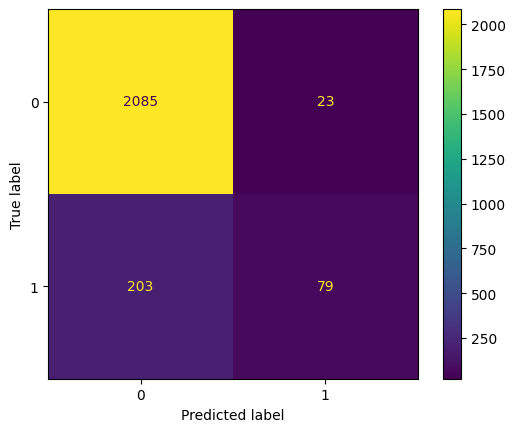

In [49]:
cm = confusion_matrix(y_stable_test, y_stable_pred)

ConfusionMatrixDisplay(cm).plot()

In [50]:
numeric_transformer_rf = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5))
])

categorical_transformer_rf = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer_rf, numeric_features),
    ("cat", categorical_transformer_rf, categorical_features)
])

model_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42
    ))
])

In [51]:
model_rf.fit(X_stable_train, y_stable_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer())]),
                                                  ['person_age',
                                                   'person_emp_length',
                                                   'loan_percent_income',
                                                   'cb_person_default_on_file']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['loan_intent',
                                                   'loan_grade'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [52]:
y_stable_pred_rf = model_rf.predict(X_stable_test)
y_stable_proba_rf = model_rf.predict_proba(X_stable_test)[:, 1]
print("Logistic Regression Accuracy:",
      accuracy_score(y_stable_test, y_stable_pred_rf))
print("Logistic Regression Recall:", recall_score(y_stable_test, y_stable_pred_rf))
print("Logistic Regression ROC-AUC:",
      roc_auc_score(y_stable_test, y_stable_proba_rf))

Logistic Regression Accuracy: 0.90418410041841
Logistic Regression Recall: 0.3617021276595745
Logistic Regression ROC-AUC: 0.7937181221150094


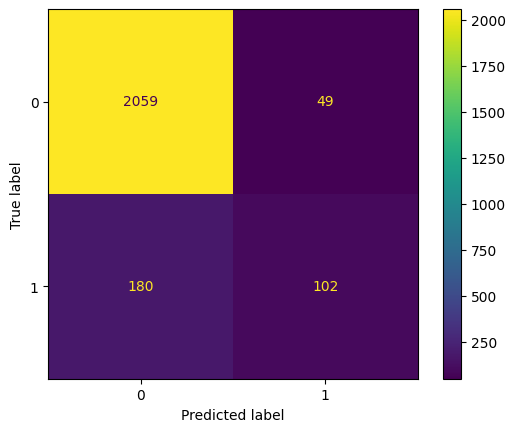

In [53]:
cm = confusion_matrix(y_stable_test, y_stable_pred_rf)

ConfusionMatrixDisplay(cm).plot()

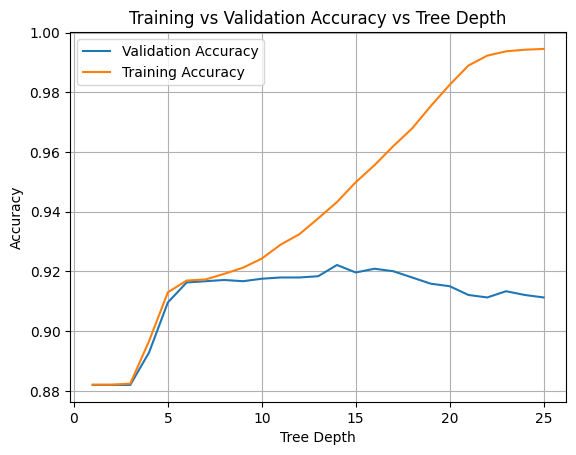

In [54]:
Val_acc = []
Train_acc = []

numeric_transformer_rf = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5))
])

categorical_transformer_rf = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer_rf, numeric_features),
    ("cat", categorical_transformer_rf, categorical_features)
])
for d in range(1, 26):
    model_rf = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            max_depth=d,
            # class_weight="balanced",
            random_state=42
        ))
    ])
    model_rf.fit(X_stable_train, y_stable_train)
    Val_acc.append(model_rf.score(X_stable_val, y_stable_val))
    Train_acc.append(model_rf.score(X_stable_train, y_stable_train))


plt.plot(range(1, 26), Val_acc, label="Validation Accuracy")
plt.plot(range(1, 26), Train_acc, label="Training Accuracy")
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy vs Tree Depth")
plt.grid()
plt.legend()

In [55]:
model_rf_final = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            max_depth=14,
            # class_weight="balanced",
            # n_estimators=5,
            random_state=42
        ))
    ])
model_rf_final.fit(X_stable_train, y_stable_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer())]),
                                                  ['person_age',
                                                   'person_emp_length',
                                                   'loan_percent_income',
                                                   'cb_person_default_on_file']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['loan_intent',
                                                   'loan_grade'])])),
                ('classifier',
                 RandomForestClassifier(max_depth=14, random_state=42))])

In [56]:
y_stable_pred_rf = model_rf_final.predict(X_stable_test)
y_stable_proba_rf = model_rf_final.predict_proba(X_stable_test)[:, 1]
print("Logistic Regression Accuracy:",
      accuracy_score(y_stable_test, y_stable_pred_rf))
print("Logistic Regression Recall:", recall_score(
    y_stable_test, y_stable_pred_rf))
print("Logistic Regression ROC-AUC:",
      roc_auc_score(y_stable_test, y_stable_proba_rf))

Logistic Regression Accuracy: 0.9163179916317992
Logistic Regression Recall: 0.35815602836879434
Logistic Regression ROC-AUC: 0.8093752943868007


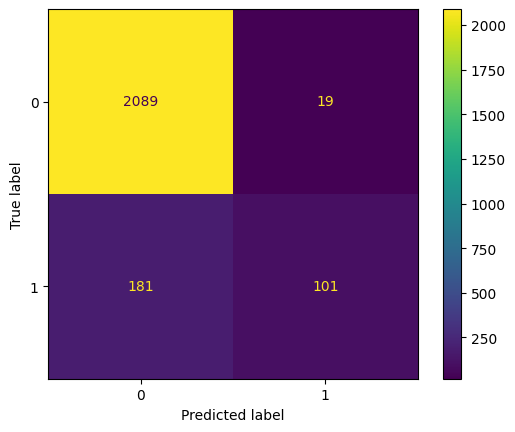

In [57]:
cm = confusion_matrix(y_stable_test, y_stable_pred_rf)

ConfusionMatrixDisplay(cm).plot()

In [ ]:
# from imblearn.over_sampling import SMOTENC
# from sklearn.model_selection import GridSearchCV

In [59]:
# param_grid = {
#     "classifier__n_estimators": [200, 300],
#     "classifier__max_depth": [12, 14, 16],
#     "classifier__min_samples_split": [2, 5],
#     "classifier__min_samples_leaf": [1, 2],
#     "classifier__max_features": ["sqrt", "log2"]
# }

In [60]:
X_nonstable = nonstable_df.drop('loan_status', axis=1)
y_nonstable = nonstable_df['loan_status']

X_nonstable_train, X_nonstable_temp, y_nonstable_train, y_nonstable_temp = train_test_split(
    X_nonstable,
    y_nonstable,
    test_size=0.30,
    stratify=y_nonstable,
    random_state=42
)

X_nonstable_val, X_nonstable_test, y_nonstable_val, y_nonstable_test = train_test_split(
    X_nonstable_temp,
    y_nonstable_temp,
    test_size=0.50,
    stratify=y_nonstable_temp,
    random_state=42
)

In [61]:
nonstable_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16484 entries, 0 to 32415
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  16105 non-null  float64
 1   person_income               16484 non-null  int64  
 2   person_emp_length           16116 non-null  float64
 3   loan_intent                 16484 non-null  object 
 4   loan_grade                  16484 non-null  object 
 5   loan_amnt                   16484 non-null  int64  
 6   loan_int_rate               14931 non-null  float64
 7   loan_status                 16484 non-null  int64  
 8   loan_percent_income         16484 non-null  float64
 9   cb_person_default_on_file   16484 non-null  int64  
 10  cb_person_cred_hist_length  16484 non-null  int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 1.5+ MB


In [62]:
X_nonstable_train.drop(
    columns=["cb_person_cred_hist_length", "loan_amnt", "loan_int_rate", "person_income"], inplace=True)
X_nonstable_val.drop(
    columns=["cb_person_cred_hist_length", "loan_amnt", "loan_int_rate", "person_income"], inplace=True)
X_nonstable_test.drop(
    columns=["cb_person_cred_hist_length", "loan_amnt", "loan_int_rate", "person_income"], inplace=True)

In [63]:
X_nonstable_train.describe()

,person_age,person_emp_length,loan_percent_income,cb_person_default_on_file
count,11289.000000,11271.000000,11538.000000,11538.000000
mean,26.921959,3.855204,0.182944,0.202375
std,4.981275,3.553292,0.110725,0.401788
min,20.000000,0.000000,0.000000,0.000000
25%,23.000000,1.000000,0.100000,0.000000
50%,25.000000,3.000000,0.160000,0.000000
75%,29.000000,6.000000,0.250000,0.000000
max,44.000000,41.000000,0.770000,1.000000


In [64]:
numeric_features = list(X_nonstable_train.select_dtypes("number").columns)
categorical_features = list(X_nonstable_train.select_dtypes("object").columns)

In [65]:
numeric_transformer = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

nonstable_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [66]:
nonstable_model.fit(X_nonstable_train, y_nonstable_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_emp_length',
                                                   'loan_percent_income',
                                                   'cb_person_default_on_file']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['loan_intent',
                                                   'loan_grade'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [67]:
y_nonstable_pred = nonstable_model.predict(X_nonstable_test)
y_nonstable_proba = nonstable_model.predict_proba(X_nonstable_test)[:, 1]
print("Logistic Regression Accuracy:",
      accuracy_score(y_nonstable_test, y_nonstable_pred))
print("Logistic Regression Recall:", recall_score(y_nonstable_test, y_nonstable_pred))
print("Logistic Regression ROC-AUC:",
      roc_auc_score(y_nonstable_test, y_nonstable_proba))

Logistic Regression Accuracy: 0.855640921957137
Logistic Regression Recall: 0.6927016645326505
Logistic Regression ROC-AUC: 0.8800440727321159


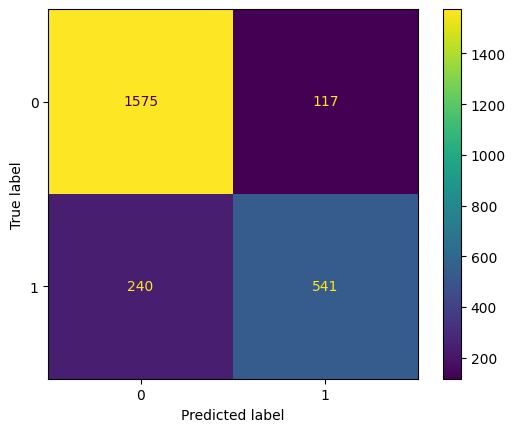

In [68]:
cm = confusion_matrix(y_nonstable_test, y_nonstable_pred)

ConfusionMatrixDisplay(cm).plot()

In [69]:
numeric_transformer_rf = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5))
])

categorical_transformer_rf = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer_rf, numeric_features),
    ("cat", categorical_transformer_rf, categorical_features)
])

nonstable_model_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42
    ))
])

In [70]:
nonstable_model_rf.fit(X_nonstable_train, y_nonstable_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer())]),
                                                  ['person_age',
                                                   'person_emp_length',
                                                   'loan_percent_income',
                                                   'cb_person_default_on_file']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['loan_intent',
                                                   'loan_grade'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [71]:
y_nonstable_pred_rf = nonstable_model_rf.predict(X_nonstable_test)
y_nonstable_proba_rf = nonstable_model_rf.predict_proba(X_nonstable_test)[:, 1]
print("Logistic Regression Accuracy:",
      accuracy_score(y_nonstable_test, y_nonstable_pred_rf))
print("Logistic Regression Recall:", recall_score(
    y_nonstable_test, y_nonstable_pred_rf))
print("Logistic Regression ROC-AUC:",
      roc_auc_score(y_nonstable_test, y_nonstable_proba_rf))

Logistic Regression Accuracy: 0.895673271330368
Logistic Regression Recall: 0.7464788732394366
Logistic Regression ROC-AUC: 0.8970382579162921


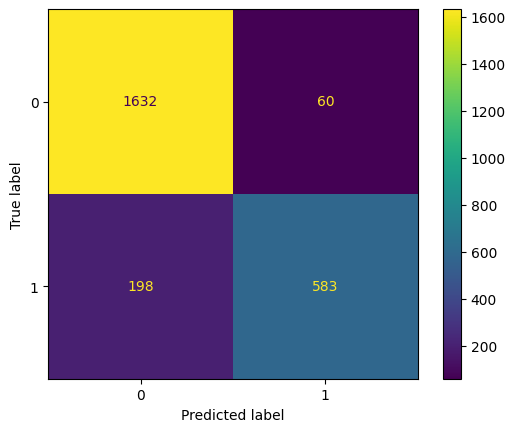

In [72]:
cm = confusion_matrix(y_nonstable_test, y_nonstable_pred_rf)

ConfusionMatrixDisplay(cm).plot()

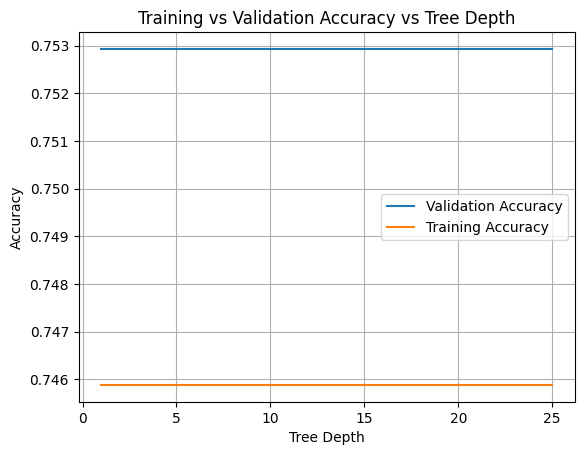

In [73]:
Val_acc = []
Train_acc = []

numeric_transformer_rf = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5))
])

categorical_transformer_rf = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer_rf, numeric_features),
    ("cat", categorical_transformer_rf, categorical_features)
])
for d in range(1, 26):
    nonstable_model_rf = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            max_depth=d,
            random_state=42
        ))
    ])
    nonstable_model_rf.fit(X_nonstable_train, y_nonstable_train)
    Val_acc.append(model_rf.score(X_nonstable_val, y_nonstable_val))
    Train_acc.append(model_rf.score(X_nonstable_train, y_nonstable_train))


plt.plot(range(1, 26), Val_acc, label="Validation Accuracy")
plt.plot(range(1, 26), Train_acc, label="Training Accuracy")
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy vs Tree Depth")
plt.grid()
plt.legend()

### Shifting from RandomForest to DecisionTree for low risk segment

### Oversampling defaulters in high risk segment

In [74]:
!pip install -q imbalanced-learn

In [76]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTENC

In [79]:
numeric_features = list(X_stable_train.select_dtypes("number").columns)
categorical_features = list(X_stable_train.select_dtypes("object").columns)

In [ ]:
cat_indices = [i for i in range(len(numeric_features), len(
    numeric_features) + len(categorical_features))]

imputer_ct = ColumnTransformer(
    transformers=[
        ('num_imputer', KNNImputer(n_neighbors=5), numeric_features)
    ],
    remainder='passthrough'  # CRITICAL: Keeps categorical columns from being dropped
)

smote_nc = SMOTENC(categorical_features=cat_indices, random_state=42)

encoder_ct = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), list(range(len(numeric_features)))),
        ('encoder', OneHotEncoder(handle_unknown='ignore'),
         cat_indices)
    ]
)

lr_model = Pipeline(steps=[
    ('imputer', imputer_ct),
    ('smote', smote_nc),
    ('preprocessor', encoder_ct),
    ('classifier', LogisticRegression(random_state=42))
])

In [86]:
lr_model.fit(X_stable_train, y_stable_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('imputer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num_imputer', KNNImputer(),
                                                  ['person_age',
                                                   'person_emp_length',
                                                   'loan_percent_income',
                                                   'cb_person_default_on_file'])])),
                ('smote',
                 SMOTENC(categorical_features=[4, 5], random_state=42)),
                ('preprocessor',
                 ColumnTransformer(transformers=[('scaler', StandardScaler(),
                                                  [0, 1, 2, 3]),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  [4, 5])])),
                ('classifier', LogisticRegression(random_state=42))])

In [87]:
y_stable_pred = lr_model.predict(X_stable_test)
y_stable_proba = lr_model.predict_proba(X_stable_test)[:, 1]
print("Logistic Regression Accuracy:",
      accuracy_score(y_stable_test, y_stable_pred))
print("Logistic Regression Recall:", recall_score(y_stable_test, y_stable_pred))
print("Logistic Regression ROC-AUC:",
      roc_auc_score(y_stable_test, y_stable_proba))

Logistic Regression Accuracy: 0.7652719665271966
Logistic Regression Recall: 0.6843971631205674
Logistic Regression ROC-AUC: 0.8074138371889593


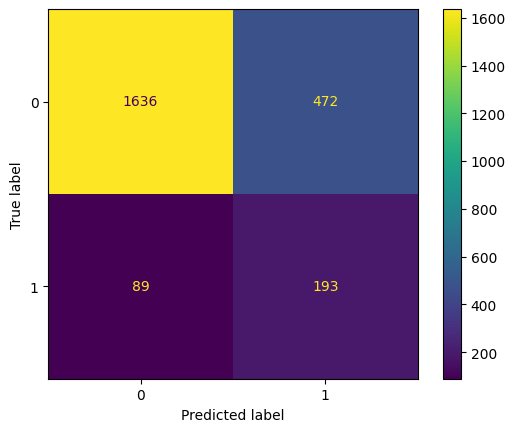

In [88]:
cm = confusion_matrix(y_stable_test, y_stable_pred)

ConfusionMatrixDisplay(cm).plot()

In [95]:
cat_indices = [i for i in range(len(numeric_features), len(
    numeric_features) + len(categorical_features))]

imputer_ct = ColumnTransformer(
    transformers=[
        ('num_imputer', KNNImputer(n_neighbors=5), numeric_features)
    ],
    remainder='passthrough'  # CRITICAL: Keeps categorical columns from being dropped
)

smote_nc = SMOTENC(categorical_features=cat_indices, random_state=42)

encoder_ct = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(handle_unknown='ignore'),
         cat_indices)
    ]
)

rf_stable_model = Pipeline(steps=[
    ('imputer', imputer_ct),
    ('smote', smote_nc),
    ('preprocessor', encoder_ct),
    ('classifier', RandomForestClassifier(
        random_state=42
    ))
])

In [96]:
rf_stable_model.fit(X_stable_train, y_stable_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('imputer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num_imputer', KNNImputer(),
                                                  ['person_age',
                                                   'person_emp_length',
                                                   'loan_percent_income',
                                                   'cb_person_default_on_file'])])),
                ('smote',
                 SMOTENC(categorical_features=[4, 5], random_state=42)),
                ('preprocessor',
                 ColumnTransformer(transformers=[('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  [4, 5])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [97]:
y_stable_pred_rf = rf_stable_model.predict(X_stable_test)
y_stable_proba_rf = rf_stable_model.predict_proba(X_stable_test)[:, 1]
print("Logistic Regression Accuracy:",
      accuracy_score(y_stable_test, y_stable_pred_rf))
print("Logistic Regression Recall:", recall_score(
    y_stable_test, y_stable_pred_rf))
print("Logistic Regression ROC-AUC:",
      roc_auc_score(y_stable_test, y_stable_proba_rf))

Logistic Regression Accuracy: 0.80418410041841
Logistic Regression Recall: 0.5106382978723404
Logistic Regression ROC-AUC: 0.7786472001291938


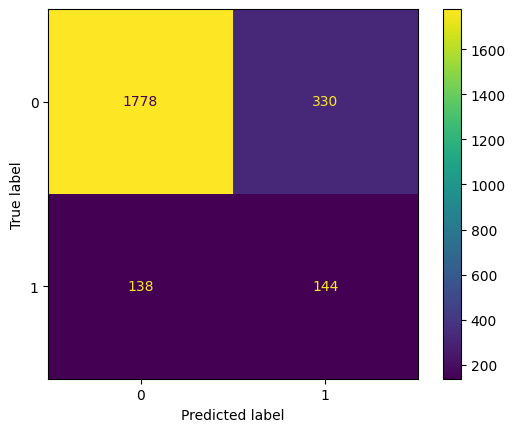

In [98]:
cm = confusion_matrix(y_stable_test, y_stable_pred_rf)

ConfusionMatrixDisplay(cm).plot()

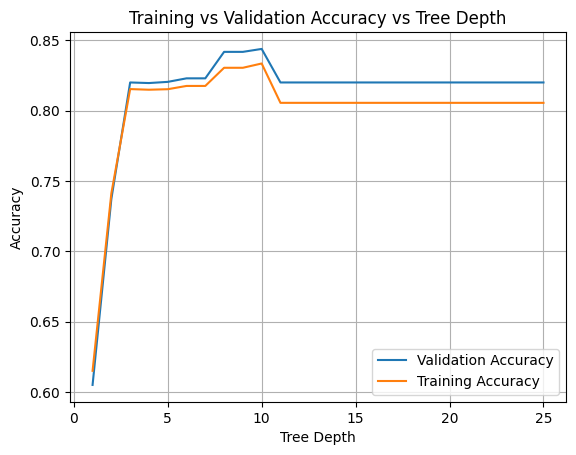

In [99]:
Val_acc = []
Train_acc = []

cat_indices = [i for i in range(len(numeric_features), len(
    numeric_features) + len(categorical_features))]

imputer_ct = ColumnTransformer(
    transformers=[
        ('num_imputer', KNNImputer(n_neighbors=5), numeric_features)
    ],
    remainder='passthrough'  # CRITICAL: Keeps categorical columns from being dropped
)

smote_nc = SMOTENC(categorical_features=cat_indices, random_state=42)

encoder_ct = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(handle_unknown='ignore'),
         cat_indices)
    ]
)

for d in range(1, 26):
    rf_stable_model = Pipeline(steps=[
        ('imputer', imputer_ct),
        ('smote', smote_nc),
        ('preprocessor', encoder_ct),
        ('classifier', RandomForestClassifier(
            max_depth=d,
            random_state=42
        ))
    ])

    rf_stable_model.fit(X_stable_train, y_stable_train)
    Val_acc.append(rf_stable_model.score(X_stable_val, y_stable_val))
    Train_acc.append(rf_stable_model.score(X_stable_train, y_stable_train))


plt.plot(range(1, 26), Val_acc, label="Validation Accuracy")
plt.plot(range(1, 26), Train_acc, label="Training Accuracy")
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy vs Tree Depth")
plt.grid()
plt.legend()

In [106]:
rf_stable_model_final = Pipeline(steps=[
    ('imputer', imputer_ct),
    ('smote', smote_nc),
    ('preprocessor', encoder_ct),
    ('classifier', RandomForestClassifier(
        max_depth=7,
        random_state=42
    ))
])

rf_stable_model_final.fit(X_stable_train, y_stable_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('imputer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num_imputer', KNNImputer(),
                                                  ['person_age',
                                                   'person_emp_length',
                                                   'loan_percent_income',
                                                   'cb_person_default_on_file'])])),
                ('smote',
                 SMOTENC(categorical_features=[4, 5], random_state=42)),
                ('preprocessor',
                 ColumnTransformer(transformers=[('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  [4, 5])])),
                ('classifier',
                 RandomForestClassifier(max_depth=7, random_state=42))])

In [107]:
y_stable_pred_rf = rf_stable_model_final.predict(X_stable_test)
y_stable_proba_rf = rf_stable_model_final.predict_proba(X_stable_test)[:, 1]
print("Logistic Regression Accuracy:",
      accuracy_score(y_stable_test, y_stable_pred_rf))
print("Logistic Regression Recall:", recall_score(
    y_stable_test, y_stable_pred_rf))
print("Logistic Regression ROC-AUC:",
      roc_auc_score(y_stable_test, y_stable_proba_rf))

Logistic Regression Accuracy: 0.8213389121338912
Logistic Regression Recall: 0.524822695035461
Logistic Regression ROC-AUC: 0.7884645793801393


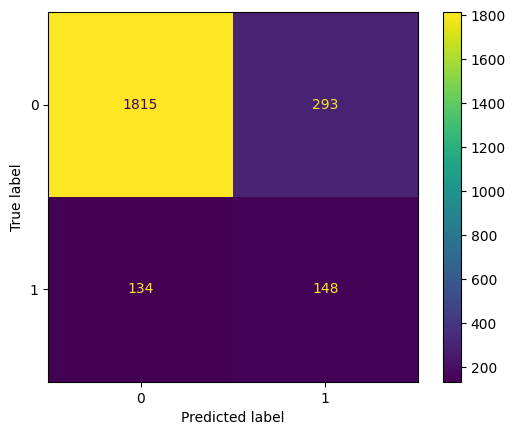

In [108]:
cm = confusion_matrix(y_stable_test, y_stable_pred_rf)

ConfusionMatrixDisplay(cm).plot()